
# Ejercicio 4: Modelo Probabilístico

**Realizado por:** Correa Adrian  
**Fecha:** 04/05/2026

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

Realizado por: Correa Adrian, fecha 04/05/2026

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import math
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import unicodedata
from nltk.corpus import stopwords
import nltk

# Descargar stopwords
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Rutas del corpus
corpus_path = r'd:\7mo semestre\RI\books2\Data'

# Cargar todos los documentos
documents = []
doc_names = []
txt_files = [filename for filename in os.listdir(corpus_path) if filename.endswith('.txt')]
expected_count = len(txt_files)

for filename in txt_files:
    filepath = os.path.join(corpus_path, filename)
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
            documents.append(text)
            doc_names.append(filename)
    except Exception as e:
        print(f"Error al leer {filename}: {e}")

print(f"Archivos .txt encontrados en la carpeta: {expected_count}")
print(f"OK: Se cargaron {len(documents)} documentos del corpus")
print(f"¿Carga completa?: {'SÍ' if len(documents) == expected_count else 'NO'}")
print(f"Primeros 5 documentos: {doc_names[:5]}")

Archivos .txt encontrados en la carpeta: 1000
OK: Se cargaron 1000 documentos del corpus
¿Carga completa?: SÍ
Primeros 5 documentos: ['20 poemas para ser leídos en el tranvía.txt', '40 years  40 años  40 ans.txt', '7 de julio.txt', "A Doll's House  a play.txt", 'A First Spanish Reader.txt']


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [ ]:
print("="*70)
print("PARTE 1: CÁLCULO DE TF, DF, IDF Y TF-IDF")
print("="*70)

# Cache de stopwords en español
SPANISH_STOPWORDS = set(stopwords.words('spanish'))

# ===== PASO 1: CONSTRUIR LA MATRIZ TF-IDF CON SKLEARN =====
print("\n[PASO 1] Vectorizando documentos (construir matriz TF-IDF)...")
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=500,
    stop_words=list(SPANISH_STOPWORDS),
    token_pattern=r'\b[a-záéíóúñ]{3,}\b',
    min_df=3,
    max_df=0.90,
    norm='l2',
    use_idf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(documents)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✓ Matriz TF-IDF construida:")
print(f"  • Dimensión: {X_tfidf.shape[0]} documentos × {X_tfidf.shape[1]} términos")
print(f"  • Tipo: matriz dispersa (sparse matrix)")

# ===== PASO 2: CALCULAR DF (DOCUMENT FREQUENCY) =====
print("\n[PASO 2] Calculando DF (Document Frequency)...")
df_counts = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()
print(f"✓ DF calculado para {len(df_counts)} términos")
print(f"  • DF mínimo: {df_counts.min()} documentos")
print(f"  • DF máximo: {df_counts.max()} documentos")
print(f"  • DF promedio: {df_counts.mean():.1f} documentos")

# ===== PASO 3: EXTRAER IDF (INVERSE DOCUMENT FREQUENCY) =====
print("\n[PASO 3] Extrayendo IDF (Inverse Document Frequency)...")
idf_scores = tfidf_vectorizer.idf_
print(f"✓ IDF extraído para {len(idf_scores)} términos")
print(f"  • IDF mínimo: {idf_scores.min():.4f}")
print(f"  • IDF máximo: {idf_scores.max():.4f}")

# ===== PASO 4: CREAR DATAFRAME CON ESTADÍSTICAS =====
print("\n[PASO 4] Visualizando en DataFrame para análisis...")
df_stats = pd.DataFrame({
    'termino': feature_names,
    'df': df_counts,
    'idf': idf_scores,
}).sort_values('idf', ascending=False)

print("\nTOP 10 TÉRMINOS MÁS RAROS (MAYOR IDF = MÁS INFORMATIVOS):")
print(df_stats.head(10)[['termino', 'df', 'idf']].to_string(index=False))

print("\nTOP 10 TÉRMINOS MÁS COMUNES (MENOR IDF = MENOS INFORMATIVOS):")
print(df_stats.tail(10)[['termino', 'df', 'idf']].to_string(index=False))

# ===== PASO 5: VISUALIZAR MATRIZ TF-IDF EN DATAFRAME =====
print("\n[PASO 5] Vista de la matriz TF-IDF (primeros 5 documentos):")
top_terms = df_stats.head(10)['termino'].tolist()
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(), 
    columns=feature_names,
    index=[f"Doc{i}" for i in range(5)]
)[top_terms]

print("\nMatriz TF-IDF (normalizadas L2) - Top 10 términos por IDF:")
print(tfidf_df.round(4).to_string())

PARTE 1: CÁLCULO DE TF, DF, IDF Y TF-IDF

[PASO 1] Vectorizando documentos (construir matriz TF-IDF)...
✓ Matriz TF-IDF construida:
  • Dimensión: 1000 documentos × 500 términos
  • Tipo: matriz dispersa (sparse matrix)

[PASO 2] Calculando DF (Document Frequency)...
✓ DF calculado para 500 términos
  • DF mínimo: 21 documentos
  • DF máximo: 899 documentos
  • DF promedio: 607.5 documentos

[PASO 3] Extrayendo IDF (Inverse Document Frequency)...
✓ IDF extraído para 500 términos
  • IDF mínimo: 1.1064
  • IDF máximo: 4.8177

[PASO 4] Visualizando en DataFrame para análisis...

TOP 10 TÉRMINOS MÁS RAROS (MAYOR IDF = MÁS INFORMATIVOS):
 termino  df      idf
     ang  21 4.817712
footnote  56 3.865704
     thy  88 3.420118
    thee  92 3.376155
    thou  98 3.313635
    went 124 3.080441
    eyes 128 3.048942
  though 132 3.018406
    came 133 3.010915
  father 133 3.010915

TOP 10 TÉRMINOS MÁS COMUNES (MENOR IDF = MENOS INFORMATIVOS):
termino  df      idf
  mismo 882 1.125430
   toda 883

## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [ ]:
print("="*70)
print("PARTE 2: RANKING DE DOCUMENTOS USANDO TF-IDF")
print("="*70)

# Consulta de prueba
query = "amor y pasión en la vida"
print(f"\nConsulta: '{query}'")
print("-" * 70)

# ===== PASO 1: CONSTRUIR VECTOR DE CONSULTA =====
print("\n[PASO 1] Construyendo vector de consulta...")
query_vector = tfidf_vectorizer.transform([query])
print(f"✓ Vector de consulta construido")
print(f"  • Dimensión: {query_vector.shape}")
print(f"  • Términos no nulos: {query_vector.nnz}")

# ===== PASO 2: CALCULAR SIMILITUD COSENO =====
print("\n[PASO 2] Calculando similitud coseno...")
similarities = cosine_similarity(query_vector, X_tfidf).flatten()
print(f"✓ Similitud coseno calculada para {len(similarities)} documentos")
print(f"  • Máxima similitud: {similarities.max():.6f}")
print(f"  • Mínima similitud: {similarities.min():.6f}")
print(f"  • Documentos con similitud > 0: {np.sum(similarities > 0)}")

# ===== PASO 3: CREAR RANKING =====
print("\n[PASO 3] Generando ranking...")
ranking_tfidf = []
for doc_id, similarity in enumerate(similarities):
    ranking_tfidf.append({
        'doc_id': doc_id,
        'documento': doc_names[doc_id],
        'score': similarity
    })

ranking_tfidf_sorted = sorted(ranking_tfidf, key=lambda x: x['score'], reverse=True)
print(f"✓ Ranking generado y ordenado por relevancia")

# ===== PASO 4: MOSTRAR RESULTADOS EN TABLA =====
print("\n[PASO 4] TOP 15 Documentos más relevantes:\n")
df_ranking_tfidf = pd.DataFrame(ranking_tfidf_sorted[:15])
df_ranking_tfidf['rank'] = range(1, len(df_ranking_tfidf) + 1)
df_ranking_tfidf = df_ranking_tfidf[['rank', 'documento', 'score']]
df_ranking_tfidf['score'] = df_ranking_tfidf['score'].round(4)
print(df_ranking_tfidf.to_string(index=False))

PARTE 2: RANKING DE DOCUMENTOS USANDO TF-IDF

Consulta: 'amor y pasión en la vida'
----------------------------------------------------------------------

[PASO 1] Construyendo vector de consulta...
✓ Vector de consulta construido
  • Dimensión: (1, 500)
  • Términos no nulos: 2

[PASO 2] Calculando similitud coseno...
✓ Similitud coseno calculada para 1000 documentos
  • Máxima similitud: 0.469718
  • Mínima similitud: 0.000000
  • Documentos con similitud > 0: 883

[PASO 3] Generando ranking...
✓ Ranking generado y ordenado por relevancia

[PASO 4] TOP 15 Documentos más relevantes:

 rank                                                                           documento  score
    1                                         El infierno del amor leyenda fantastica.txt 0.4697
    2                                           La simulación en la lucha por la vida.txt 0.4349
    3                                                               Místicas; poesías.txt 0.4347
    4               

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [4]:
print("="*70)
print("PARTE 3: RANKING CON BM25")
print("="*70)

# Clase BM25 mejorada - usa el vocabulario de TF-IDF
class BM25:
    def __init__(self, tfidf_matrix, feature_names, documents, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.N = len(documents)
        self.tfidf_matrix = tfidf_matrix
        self.feature_names = feature_names
        self.vocab_dict = {name: idx for idx, name in enumerate(feature_names)}

        print(f"\n[PASO 1] Inicializando BM25 con vocabulario consistente...")
        print(f"  Documentos: {self.N}")
        print(f"  Vocabulario: {len(self.feature_names)} términos (mismo que TF-IDF)")

        print(f"[PASO 2] Calculando DF e IDF RSJ...")
        self.idf_scores = {}
        for idx, term in enumerate(self.feature_names):
            df = int((self.tfidf_matrix[:, idx] > 0).sum())
            idf = math.log((self.N - df + 0.5) / (df + 0.5))
            idf = max(0.1, idf)
            self.idf_scores[term] = idf

        print(f"[PASO 3] Calculando longitudes de documentos...")
        self.doc_vectors = self.tfidf_matrix.toarray()
        self.doc_lengths = []
        for doc_vec in self.doc_vectors:
            tf_sum = np.sum(doc_vec > 0)
            self.doc_lengths.append(tf_sum)

        self.avg_doc_length = np.mean(self.doc_lengths) if self.doc_lengths else 1
        print(f"  Promedio longitud documento: {self.avg_doc_length:.1f} términos")
        print("  Preprocesamiento completado")

    def score_document(self, query_terms, doc_id):
        score = 0.0
        doc_length = self.doc_lengths[doc_id]
        norm = 1 - self.b + self.b * (doc_length / self.avg_doc_length)

        for term in query_terms:
            if term not in self.vocab_dict:
                continue

            term_idx = self.vocab_dict[term]
            tf = self.doc_vectors[doc_id][term_idx]

            if tf > 0:
                idf = self.idf_scores[term]
                score += idf * ((self.k1 + 1) * tf) / (self.k1 * norm + tf)

        return score

    def rank_documents(self, query, vectorizer):
        query_vec = vectorizer.transform([query])
        query_terms = [self.feature_names[idx] for idx in query_vec[0].nonzero()[1]]

        scores = [(doc_id, self.score_document(query_terms, doc_id))
                  for doc_id in range(self.N)]
        return sorted(scores, key=lambda x: x[1], reverse=True)

print("\n[PASO 1-3] Inicializando modelo BM25...")
print(f"  k1 = 1.5 (saturación de TF)")
print(f"  b = 0.75 (normalización por longitud)")
bm25_model = BM25(X_tfidf, feature_names, documents, k1=1.5, b=0.75)

print(f"\n[PASO 4] Rankeando documentos con consulta: '{query}'")
ranking_bm25_raw = bm25_model.rank_documents(query, tfidf_vectorizer)
ranking_bm25 = [{'doc_id': doc_id, 'documento': doc_names[doc_id], 'score': score}
                for doc_id, score in ranking_bm25_raw]

score_values = [s for _, s in ranking_bm25_raw]
print(f"  Ranking completado")
print(f"  Score máximo: {max(score_values):.6f}")
print(f"  Score mínimo: {min(score_values):.6f}")
print(f"  Documentos con score > 0: {sum(1 for s in score_values if s > 0)}")

print(f"\n[PASO 5] TOP 15 Documentos más relevantes:\n")
df_ranking_bm25 = pd.DataFrame(ranking_bm25[:15])
df_ranking_bm25['rank'] = range(1, len(df_ranking_bm25) + 1)
df_ranking_bm25 = df_ranking_bm25[['rank', 'documento', 'score']]
df_ranking_bm25['score'] = df_ranking_bm25['score'].round(6)
print(df_ranking_bm25.to_string(index=False))

PARTE 3: RANKING CON BM25

[PASO 1-3] Inicializando modelo BM25...
  k1 = 1.5 (saturación de TF)
  b = 0.75 (normalización por longitud)

[PASO 1] Inicializando BM25 con vocabulario consistente...
  Documentos: 1000
  Vocabulario: 500 términos (mismo que TF-IDF)
[PASO 2] Calculando DF e IDF RSJ...
[PASO 3] Calculando longitudes de documentos...
  Promedio longitud documento: 303.8 términos
  Preprocesamiento completado

[PASO 4] Rankeando documentos con consulta: 'amor y pasión en la vida'
  Ranking completado
  Score máximo: 0.134220
  Score mínimo: 0.000000
  Documentos con score > 0: 883

[PASO 5] TOP 15 Documentos más relevantes:

 rank                                                                           documento    score
    1                                                               Místicas; poesías.txt 0.134220
    2                                                           A Flor De Piel Frases.txt 0.125647
    3                                         El infierno de

In [18]:
print("\n" + "="*70)
print("DIAGNOSTICO: Análisis de scores BM25")
print("="*70)

query_vec = tfidf_vectorizer.transform([query])
query_term_indices = query_vec[0].nonzero()[1]
query_terms = [feature_names[idx] for idx in query_term_indices]

print(f"\nTérminos en consulta: {query_terms}")
for term in query_terms:
    term_idx = [i for i, ft in enumerate(feature_names) if ft == term][0]
    df = int((X_tfidf[:, term_idx] > 0).sum())
    idf_rsj = math.log(max(1.0, (len(documents) - df + 0.5) / (df + 0.5)))
    print(f"  {term}: DF={df}, IDF_RSJ={idf_rsj:.6f}")

print(f"\nScores BM25 (Top 10):")
for i, (doc_id, score) in enumerate(ranking_bm25_raw[:10], 1):
    print(f"  {i}. {doc_names[doc_id][:50]}: {score:.6f}")


DIAGNOSTICO: Análisis de scores BM25

Términos en consulta: ['amor', 'vida']
  amor: DF=838, IDF_RSJ=0.000000
  vida: DF=874, IDF_RSJ=0.000000

Scores BM25 (Top 10):
  1. Místicas; poesías.txt: 0.134220
  2. A Flor De Piel Frases.txt: 0.125647
  3. El infierno del amor leyenda fantastica.txt: 0.105076
  4. Lira Póstuma Obras Completas Vol. XXI.txt: 0.097687
  5. Cantos de Vida y Esperanza, Los Cisnes y otros poe: 0.085925
  6. Poema del Otoño y otros poemas Obras Completas Vol: 0.076919
  7. Coplas por la muerte de su padre.txt: 0.075479
  8. Impresiones, Poesías.txt: 0.075450
  9. La simulación en la lucha por la vida.txt: 0.074979
  10. El corazón juglar.txt: 0.074947


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

PARTE 4: COMPARACIÓN VISUAL ENTRE TF-IDF Y BM25

[PASO 1] Generando gráficos...


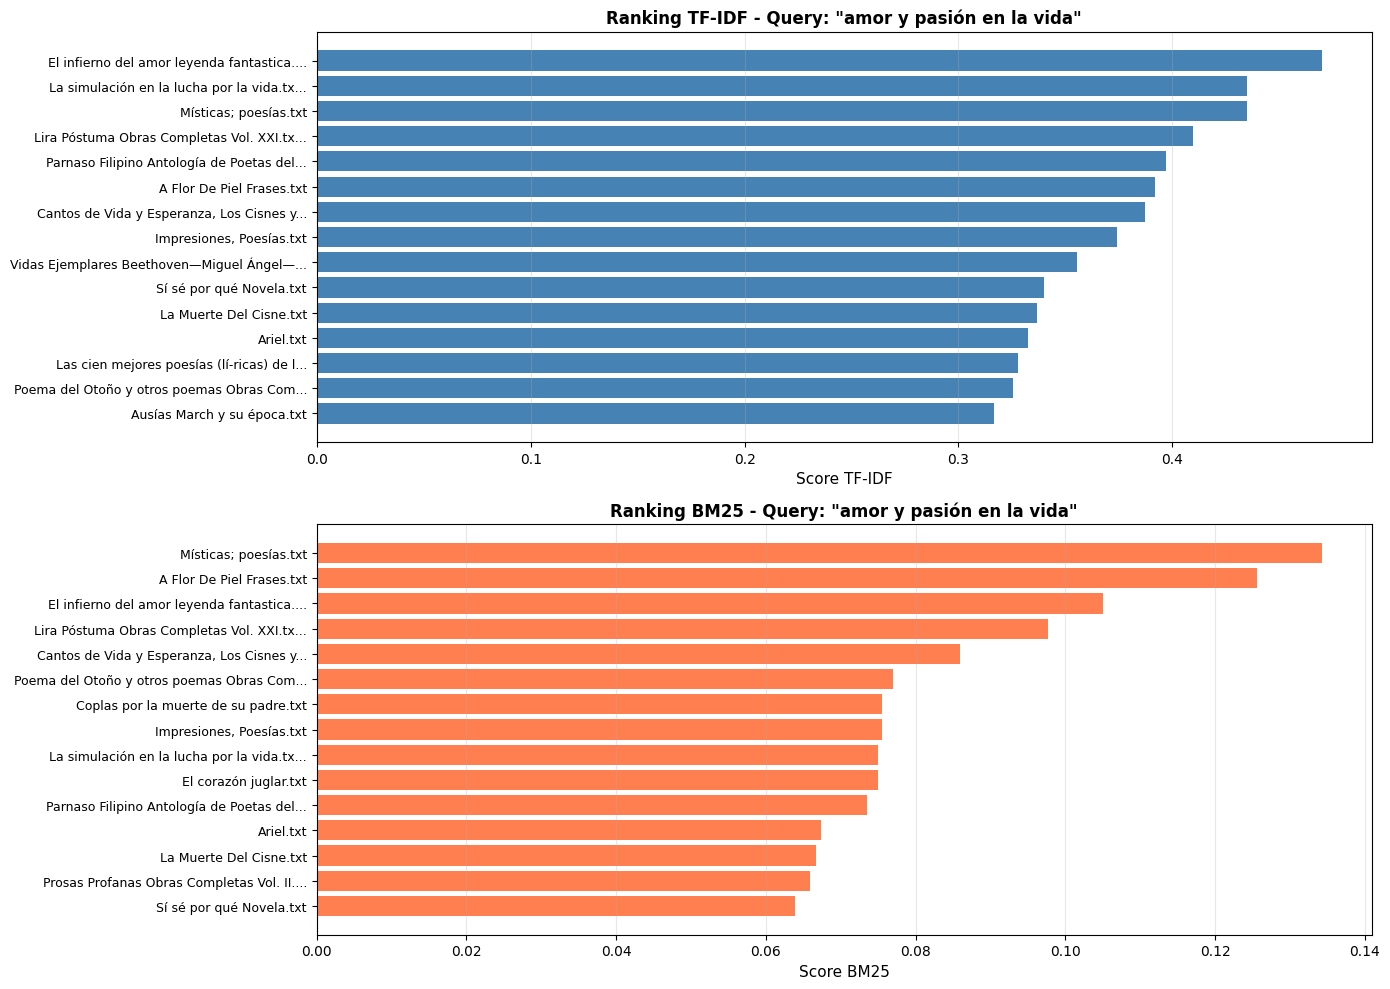

Gráfico guardado: comparacion_tfidf_bm25.png

[PASO 2] Comparando rankings visualmente...

TOP 5 - TF-IDF:
  1. El infierno del amor leyenda fantastica.txt: 0.4697
  2. La simulación en la lucha por la vida.txt: 0.4349
  3. Místicas; poesías.txt: 0.4347
  4. Lira Póstuma Obras Completas Vol. XXI.txt: 0.4097
  5. Parnaso Filipino Antología de Poetas del Archipela: 0.3972

TOP 5 - BM25:
  1. Místicas; poesías.txt: 0.134220
  2. A Flor De Piel Frases.txt: 0.125647
  3. El infierno del amor leyenda fantastica.txt: 0.105076
  4. Lira Póstuma Obras Completas Vol. XXI.txt: 0.097687
  5. Cantos de Vida y Esperanza, Los Cisnes y otros poe: 0.085925

[PASO 3] Documentos con mayor cambio de ranking (Δ > 10):

1. Estatuto de la L. F. (Liga Filipina).txt
   TF-IDF: #334, BM25: #61 (Δ=273)
2. Los Desastres de la guerra colección de ochenta lá
   TF-IDF: #426, BM25: #158 (Δ=268)
3. 20 poemas para ser leídos en el tranvía.txt
   TF-IDF: #659, BM25: #394 (Δ=265)
4. Mi Ultimo Adiós.txt
   TF-IDF: #265, 

In [ ]:
print("="*70)
print("PARTE 4: COMPARACIÓN VISUAL ENTRE TF-IDF Y BM25")
print("="*70)

# PASO 1: CREAR GRÁFICOS COMPARATIVOS
print("\n[PASO 1] Generando gráficos...")
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_n = 15

# Gráfico 1: TF-IDF
docs_tfidf = ranking_tfidf_sorted[:top_n]
names_tfidf = [d['documento'][:40] + '...' if len(d['documento']) > 40 else d['documento']
               for d in docs_tfidf]
scores_tfidf = [d['score'] for d in docs_tfidf]

axes[0].barh(range(len(names_tfidf)), scores_tfidf, color='steelblue')
axes[0].set_yticks(range(len(names_tfidf)))
axes[0].set_yticklabels(names_tfidf, fontsize=9)
axes[0].set_xlabel('Score TF-IDF', fontsize=11)
axes[0].set_title(f'Ranking TF-IDF - Query: "{query}"', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: BM25
docs_bm25 = ranking_bm25[:top_n]
names_bm25 = [d['documento'][:40] + '...' if len(d['documento']) > 40 else d['documento']
              for d in docs_bm25]
scores_bm25 = [d['score'] for d in docs_bm25]

axes[1].barh(range(len(names_bm25)), scores_bm25, color='coral')
axes[1].set_yticks(range(len(names_bm25)))
axes[1].set_yticklabels(names_bm25, fontsize=9)
axes[1].set_xlabel('Score BM25', fontsize=11)
axes[1].set_title(f'Ranking BM25 - Query: "{query}"', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(r'd:\7mo semestre\RI\books2\EJERCICIO-04\comparacion_tfidf_bm25.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado: comparacion_tfidf_bm25.png")

# PASO 2: COMPARAR RANKINGS
print("\n[PASO 2] Comparando rankings visualmente...\n")

print("TOP 5 - TF-IDF:")
for i, doc in enumerate(ranking_tfidf_sorted[:5], 1):
    print(f"  {i}. {doc['documento'][:50]}: {doc['score']:.4f}")

print("\nTOP 5 - BM25:")
for i, doc in enumerate(ranking_bm25[:5], 1):
    print(f"  {i}. {doc['documento'][:50]}: {doc['score']:.6f}")

# PASO 3: DOCUMENTOS CON MAYOR CAMBIO DE RANKING
print("\n[PASO 3] Documentos con mayor cambio de ranking (Δ > 10):\n")

tfidf_rank = {doc['doc_id']: i+1 for i, doc in enumerate(ranking_tfidf_sorted)}
bm25_rank = {doc['doc_id']: i+1 for i, doc in enumerate(ranking_bm25)}

changes = []
for doc_id in range(len(documents)):
    tfidf_pos = tfidf_rank.get(doc_id, 999)
    bm25_pos = bm25_rank.get(doc_id, 999)
    delta = abs(tfidf_pos - bm25_pos)
    if delta > 10:
        changes.append({
            'doc': doc_names[doc_id],
            'tfidf': tfidf_pos,
            'bm25': bm25_pos,
            'delta': delta
        })

changes = sorted(changes, key=lambda x: x['delta'], reverse=True)[:10]
for i, ch in enumerate(changes, 1):
    print(f"{i}. {ch['doc'][:50]}")
    print(f"   TF-IDF: #{ch['tfidf']}, BM25: #{ch['bm25']} (Δ={ch['delta']})")

# PASO 4: ANÁLISIS DE DIFERENCIAS
print("\n" + "="*70)
print("[PASO 4] ANÁLISIS DE DIFERENCIAS")
print("="*70)

print("\n¿Por qué hay diferencias entre los rankings?")
print("\nTF-IDF:")
print("  - Favorece documentos con términos raros (alto IDF)")
print("  - No considera la longitud del documento")
print("  - Score basado solo en presencia/ausencia ponderada")

print("\nBM25:")
print("  - Saturación de TF: ganancia marginal de un término disminuye")
print("  - Normalización por longitud: favorece documentos cortos relevantes")
print("  - Más robusto ante variabilidad de longitudes en el corpus")

print("\nConclusión:")
print("BM25 generalmente produce rankings más equilibrados que TF-IDF")
print("porque considera tanto la importancia del término como la estructura")
print("del documento (longitud y saturación de frecuencia).")